# MLflow avanzado: tracking + HPO (Optuna)

Este notebook tiene dos objetivos:

1) **Tracking (experimentos y runs)**
- Guardar parámetros, métricas, tags y artifacts (archivos como `.csv`, `.png`, etc.).
- Comparar resultados entre runs.

2) **Optimización de hiperparámetros (Optuna) con MLflow**
- Un *parent run* representa el estudio.
- Cada *trial* se guarda como un *child run* (`nested=True`).

> Nota importante (para no confundirse):
>
>- **Loggear un modelo** (`mlflow.<flavor>.log_model`) significa guardarlo como artifact *dentro de un run*.
>- **Registrar un modelo** (Model Registry) significa crear un nombre de “modelo” global con **versiones** (v1, v2, ...) que apuntan a runs.
>
> En este notebook el foco principal es **tracking + Optuna**. El Model Registry aparece al final como material complementario.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np


## **Cargamos datos "procesados"**

In [2]:
df_jan = pd.read_parquet("data/processed/jan.parquet")
df_feb = pd.read_parquet("data/processed/feb.parquet")


## **Definir columnas a modelar**

In [3]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ["trip_distance"]

## Definir set de train y test

In [4]:
df_train = df_jan
df_val = df_feb

## **Preprocesar**

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df_train = df_train.copy()
df_val   = df_val.copy()
df_train["categorical_dict"] = df_train[categorical].to_dict(orient="records")
df_val["categorical_dict"]   = df_val[categorical].to_dict(orient="records")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", DictVectorizer(), "categorical_dict"),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numerical),
    ]
)

X_train = preprocessor.fit_transform(df_train)
y_train = df_train["duration"].values
X_val   = preprocessor.transform(df_val)
y_val   = df_val["duration"].values

## **Entrenar**

Antes de ejecutar lo siguiente, levanta el **MLflow Tracking Server** en una terminal (en la raíz del proyecto):

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5000 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```

Luego abre la UI en:

- http://127.0.0.1:5000

## ¿Qué crea esto en tu proyecto?

- `mlflow.db`:
  - Base de datos (SQLite) con la **metadata** del tracking (experimentos, runs, params, metrics, etc.).

- `mlruns/`:
  - Carpeta donde MLflow guarda los **artifacts** (archivos) de cada run.
  - Dentro de cada run verás `artifacts/` (por ejemplo: predicciones, plots, modelos loggeados).

In [6]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


## Cómo leer la carpeta `mlruns/` (muy importante)

Cuando ejecutas runs con MLflow, lo común es ver algo así:

- `mlruns/<experiment_id>/<run_id>/`:
  - `metrics/`, `params/`, `tags/`: archivos internos que MLflow usa para tracking.
  - `artifacts/`: **archivos que tú registras** (CSVs, PNGs, etc.).
    - Si haces `mlflow.<flavor>.log_model(..., name="model")`, MLflow guarda el modelo en:
      - `mlruns/<experiment_id>/<run_id>/artifacts/model/`

### ¿Y la carpeta `mlruns/models/`?

- Esa carpeta aparece cuando está habilitado el **Model Registry** (depende de cómo esté configurado el server/backend).
- No es “un modelo por run”. Es el **catálogo**:
  - Un **Registered Model** (un nombre)
  - Con varias **versiones** (v1, v2, ...) que apuntan a runs.

Regla mental:

- **Run** = una ejecución (con artifacts, incluyendo el modelo loggeado).
- **Registry** = un índice/catálogo que organiza “el mismo modelo” en versiones.

In [7]:

experiment_name = "nyc-first-experiment"

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="rf_baseline"):
    rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))

    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("random_state", 0)
    mlflow.log_metric("rmse", rmse)

    rmse

2026/03/25 20:57:47 INFO mlflow.tracking.fluent: Experiment with name 'nyc-first-experiment' does not exist. Creating a new experiment.


🏃 View run rf_baseline at: http://127.0.0.1:5001/#/experiments/3/runs/d9d20a1fac1a4da7892ae8d1069a17bd
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


## **Probando otro modelo**

In [8]:
import xgboost as xgb

experiment_name = "nyc-taxi-baseline"
mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="xgb_baseline"):
    xgb_reg = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
    xgb_reg.fit(X_train, y_train)
    y_pred = xgb_reg.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    mlflow.log_param("objective", "reg:squarederror")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("rmse", rmse)

    rmse

2026/03/25 20:58:28 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-baseline' does not exist. Creating a new experiment.


🏃 View run xgb_baseline at: http://127.0.0.1:5001/#/experiments/4/runs/2e5fb32d3cb741febeaa3a154848e67a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


## **Probando autologging**

`mlflow.autolog()` captura automáticamente muchos parámetros, métricas y artifacts del entrenamiento.

Nota: MLflow puede mostrar warnings si la versión instalada de XGBoost no está dentro del rango recomendado para autologging.

In [9]:
import mlflow

experiment_name = "nyc-taxi-autolog"
mlflow.set_experiment(experiment_name)

mlflow.autolog()

mlflow.enable_system_metrics_logging()

with mlflow.start_run(run_name="rf_autolog") as run:
    rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    mlflow.log_metric("rmse_manual", rmse)


    rmse

print(mlflow.MlflowClient().get_run(run.info.run_id).data)

2026/03/25 20:58:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/03/25 20:58:36 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.0.0 <= xgboost <= 3.0.2, but the installed version is 3.0.4. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
2026/03/25 20:58:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/03/25 20:58:36 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/25 20:58:36 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/25 20:58:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 20:58:42 INFO mlflow.system_metrics.system_metrics_monitor: Stop

🏃 View run rf_autolog at: http://127.0.0.1:5001/#/experiments/2/runs/7dcc1f0c8901478892758fc00fcb18e1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
<RunData: metrics={'rmse_manual': 5.137713717868471,
 'training_mean_absolute_error': 3.11467202167165,
 'training_mean_squared_error': 22.407621803552562,
 'training_r2_score': 0.7248164394449219,
 'training_root_mean_squared_error': 4.7336689579598366,
 'training_score': 0.7248164394449219}, params={'bootstrap': 'True',
 'ccp_alpha': '0.0',
 'criterion': 'squared_error',
 'max_depth': '10',
 'max_features': '1.0',
 'max_leaf_nodes': 'None',
 'max_samples': 'None',
 'min_impurity_decrease': '0.0',
 'min_samples_leaf': '1',
 'min_samples_split': '2',
 'min_weight_fraction_leaf': '0.0',
 'monotonic_cst': 'None',
 'n_estimators': '100',
 'n_jobs': 'None',
 'oob_score': 'False',
 'random_state': '0',
 'verbose': '0',
 'warm_start': 'False'}, tags={'estimator_class': 'sklearn.ensemble._forest.RandomForestRegressor',
 'estimator_na

In [11]:
from mlflow.tracking import MlflowClient
client = MlflowClient()
 
run_id = "7dcc1f0c8901478892758fc00fcb18e1" # reemplazar con el run_id del experimento
client.list_artifacts(run_id)
client.list_artifacts(run_id, path="model")

[<FileInfo: file_size=990, is_dir=False, path='model/MLmodel'>,
 <FileInfo: file_size=221, is_dir=False, path='model/conda.yaml'>,
 <FileInfo: file_size=11139689, is_dir=False, path='model/model.pkl'>,
 <FileInfo: file_size=99, is_dir=False, path='model/python_env.yaml'>,
 <FileInfo: file_size=107, is_dir=False, path='model/requirements.txt'>]

## **Optimización de Hiperparametros**

## **Usando Optuna + MLflow (nested runs)**

En esta sección:

- Creamos un *parent run* que representa el estudio completo.
- Cada trial se guarda como un *child run* (`nested=True`).
- Loggeamos artifacts útiles: `optuna_top_trials.csv` y `optuna_best_params.json`.

Así, en la UI de MLflow puedes ver el estudio completo y, dentro, cada trial con sus hiperparámetros y métrica.

Optimizar los hiperparámetros no es solo cuestión de probar al azar: es un proceso sistemático para encontrar la mejor combinación posible, y así lograr que nuestro modelo aprenda mejor y generalice bien a datos nuevos. Si no los ajustamos, podemos quedarnos con un modelo que no aprovecha todo su potencial.

## **Usando Optuna**

Optuna prueba combinaciones de hiperparámetros, aprende de los resultados y se enfoca en las opciones más prometedoras, ahorrando tiempo y esfuerzo.

En este notebook, además de optimizar, vamos a **registrar cada trial en MLflow** para poder comparar en la UI.

(Opcional) Puedes ignorar este diagrama. Lo importante es que Optuna explorará hiperparámetros y MLflow guardará los resultados de cada trial.

## Explorando la MLflow UI (qué mirar sin perderse)

Abre la UI:

- http://127.0.0.1:5000

### 1) Experiments
- Aquí ves la lista de experimentos (por ejemplo `nyc-taxi-baseline-experiment`, `nyc-taxi-autolog`, `nyc-taxi-hpo`).

### 2) Runs
- Dentro de un experimento, cada entrenamiento es un **run**.
- En la parte de Optuna:
  - El run `optuna_study` es el **parent run**.
  - Los runs `trial_0`, `trial_1`, ... son **child runs** (nested).

### 3) Params, Metrics y Tags
- `Params`: hiperparámetros.
- `Metrics`: por ejemplo `rmse`.
- `Tags`: metadata (dataset, tipo de problema, familia de modelo, etc.).

### 4) Artifacts
- Aquí están los archivos del run.
- Si loggeas un modelo con `log_model`, también aparecerá como una carpeta dentro de `Artifacts`.

### 5) Models (Model Registry) (opcional)
- Solo si tu servidor tiene **Registry habilitado**, verás la pestaña **Models**.
- Ahí se organiza un modelo por **nombre** y **versiones** (v1, v2, ...).
- Ojo: que un run tenga `Artifacts/model` **no significa** que ya esté en el Registry.

## Explorando la MLflow UI

Esta sección ya está explicada arriba en **"Explorando la MLflow UI (qué mirar sin perderse)"**.

Sugerencia:
- Abre la UI en http://127.0.0.1:5000
- Entra a tu experimento (por ejemplo `nyc-taxi-hpo`)
- Revisa:
  - `Runs`
  - `Metrics`
  - `Params`
  - `Artifacts`

In [12]:
import optuna
import mlflow
import json

def objective(trial):
    # Hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    
    # Crear y entrenar el modelo
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    
    # Loggear a MLflow como nested run
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True) as run:
        mlflow.log_params(trial.params)
        mlflow.log_metric("rmse", rmse)
    
    return rmse

# Crear el estudio de Optuna
study = optuna.create_study(direction="minimize")

experiment_name = "nyc-taxi-hype-optuna"
mlflow.set_experiment(experiment_name)

# Parent run para el estudio completo
with mlflow.start_run(run_name="optuna_study") as parent_run:
    study.optimize(objective, n_trials=10)
    
    # Guardar artifacts del estudio
    # Top trials
    top_trials = sorted(study.trials, key=lambda t: t.value)[:5]
    top_trials_data = [
        {
            "trial_number": t.number,
            "rmse": t.value,
            "params": t.params
        }
        for t in top_trials
    ]
    
    # Best params
    best_params = study.best_params
    
    # Guardar como artifacts
    mlflow.log_dict(top_trials_data, "optuna_top_trials.csv")
    mlflow.log_dict(best_params, "optuna_best_params.json")
    
    print(f"Study completed. Best RMSE: {study.best_value:.4f}")
    print(f"Parent run ID: {parent_run.info.run_id}")

/Users/mdurango/Downloads/proyectos/MLOps_UdM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-25 21:09:19,067] A new study created in memory with name: no-name-cbe26f70-7fb5-4c5c-89c6-44fe766d40f5
2026/03/25 21:09:19 INFO mlflow.tracking.fluent: Experiment with name 'nyc-taxi-hype-optuna' does not exist. Creating a new experiment.
2026/03/25 21:09:19 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/25 21:09:19 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/25 21:09:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:09:22 INFO mlflow.system_m

🏃 View run trial_0 at: http://127.0.0.1:5001/#/experiments/5/runs/28ddade67a114640a0f6e156f2266556
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5


2026/03/25 21:09:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:09:24 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ade6116f804f9babbbeeba79b9840a. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'13\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'2\', \'new_value\': \'1\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'3\'}, {\'key\': \'n_estimators\', \'old_value\': \'200\', \'new_value\': \'83\'}]\' for run ID=\'e0ade6116f804f9babbbeeba79b9840a\'.")]')]
2026/03/25 21:09:24 INFO 

🏃 View run trial_1 at: http://127.0.0.1:5001/#/experiments/5/runs/a68d55d119434b25801e3b5d41f2fcbc
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5


2026/03/25 21:09:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:09:27 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ade6116f804f9babbbeeba79b9840a. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'8\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'2\', \'new_value\': \'4\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'3\'}]\' for run ID=\'e0ade6116f804f9babbbeeba79b9840a\'.")]')]
2026/03/25 21:09:27 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set l

...

🏃 View run trial_7 at: http://127.0.0.1:5001/#/experiments/5/runs/3b599fec3a1a4cfd812b992745a1d878
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5


2026/03/25 21:09:41 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:09:41 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ade6116f804f9babbbeeba79b9840a. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'15\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'2\', \'new_value\': \'1\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'4\'}, {\'key\': \'n_estimators\', \'old_value\': \'200\', \'new_value\': \'131\'}]\' for run ID=\'e0ade6116f804f9babbbeeba79b9840a\'.")]')]
2026/03/25 21:09:41 INFO

🏃 View run trial_8 at: http://127.0.0.1:5001/#/experiments/5/runs/8e160c042d2249a4a96aa8c1bf1f46ff
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5


2026/03/25 21:09:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:09:43 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: The following failures occurred while performing one or more logging operations: [MlflowException('Failed to perform one or more operations on the run with ID e0ade6116f804f9babbbeeba79b9840a. Failed operations: [RestException("INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged=\'[{\'key\': \'max_depth\', \'old_value\': \'12\', \'new_value\': \'11\'}, {\'key\': \'min_samples_leaf\', \'old_value\': \'2\', \'new_value\': \'4\'}, {\'key\': \'min_samples_split\', \'old_value\': \'7\', \'new_value\': \'5\'}, {\'key\': \'n_estimators\', \'old_value\': \'200\', \'new_value\': \'163\'}]\' for run ID=\'e0ade6116f804f9babbbeeba79b9840a\'.")]')]
2026/03/25 21:09:44 INFO

🏃 View run trial_9 at: http://127.0.0.1:5001/#/experiments/5/runs/f8d04cc90e0c4ac38bb24ea417422d69
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5
Study completed. Best RMSE: 5.0264
Parent run ID: e0ade6116f804f9babbbeeba79b9840a
🏃 View run optuna_study at: http://127.0.0.1:5001/#/experiments/5/runs/e0ade6116f804f9babbbeeba79b9840a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5


In [13]:
# Analyze the best trial
print(f"Best trial: {study.best_trial.number}")
print(f"Best value (RMSE): {study.best_value:.4f}")
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study.best_params, "random_state": 42, "n_jobs": -1}
best_model = RandomForestRegressor(**best_params)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)
rmse_best = float(np.sqrt(mean_squared_error(y_val, y_pred_best)))

print(f"\nBest model RMSE: {rmse_best:.4f}")
rmse_best

2026/03/25 21:14:20 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/25 21:14:20 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/03/25 21:14:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '40775351d3ef4f8da1742b50734147ce', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Best trial: 8
Best value (RMSE): 5.0264
Best params:
  n_estimators: 131
  max_depth: 15
  min_samples_split: 4
  min_samples_leaf: 1


2026/03/25 21:14:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/25 21:14:23 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/25 21:14:23 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run amusing-snail-547 at: http://127.0.0.1:5001/#/experiments/5/runs/40775351d3ef4f8da1742b50734147ce
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5

Best model RMSE: 5.0264


5.026373897231725

## **Visualizando la optimización de optuna**

/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_13323/602149405.py:6: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

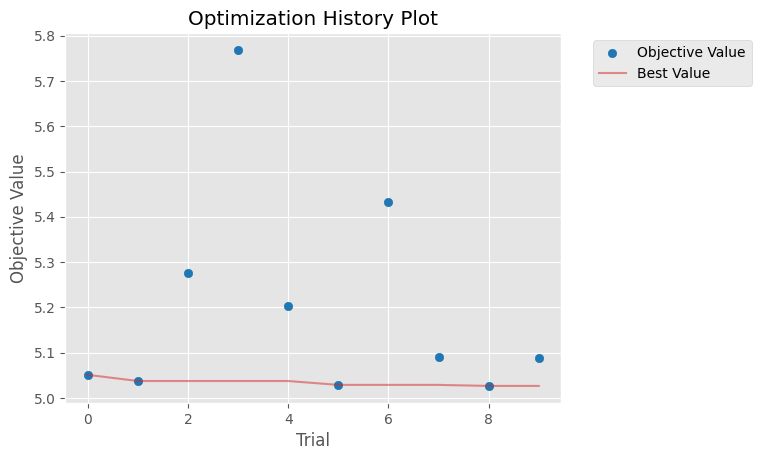

In [14]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study)



## Ideas clave antes de empezar

- **Tracking**: cada entrenamiento es un *run*.
  - Dentro del run, en `Artifacts`, puedes tener un modelo loggeado (por ejemplo `Artifacts/model`).

- **Registry**: es un "catálogo" separado, organizado por **nombre de modelo**.
  - Un mismo nombre (por ejemplo `nyc-taxi-duration-model`) puede tener versiones **v1, v2, v3...**
  - Cada versión apunta al run que la generó.

### ¿Qué vamos a hacer aquí?

1. Registrar el mejor modelo en el Model Registry.
2. Asignar **aliases** (`champion`, `candidate`) para identificar versiones clave.
3. Aprender las **3 formas de cargar un modelo** desde el Registry.
4. Hacer predicciones con el modelo cargado.

> **Analogía**: Piensa en el Registry como un "estante de modelos aprobados". El tracking es tu laboratorio donde experimentas; el Registry es la vitrina donde pones los modelos que ya están listos.

# Usando el Model Registry para guardar el mejor modelo y "ponerlo" en producción

### ¿Por qué necesitamos un Model Registry?

Hasta ahora hemos **experimentado**: probamos modelos, comparamos métricas, encontramos el mejor.
Pero en un flujo real de MLOps, después de experimentar necesitas:

1. **Guardar el modelo ganador** de forma que cualquier persona o servicio pueda encontrarlo por nombre (no buscando entre cientos de runs).
2. **Versionar** los modelos: si mañana entrenas uno mejor, quieres que sea la v2, sin perder la v1.
3. **Etiquetar** qué versión está en producción (`champion`) y cuál se está evaluando (`candidate`).

Eso es exactamente lo que hace el **Model Registry** de MLflow.

### Paso 1: Registrar el modelo

La siguiente celda hace varias cosas:
- Crea un **pipeline completo** (preprocesamiento + modelo) para que sea reproducible.
- Lo loggea como artifact en un nuevo run.
- Lo registra en el Model Registry con el nombre `nyc-taxi-duration-model`.

> Cada vez que ejecutes esta celda, se crea una **nueva versión** del modelo en el Registry.

In [15]:
# Register + promote the best model (Model Registry)

import mlflow
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature
from sklearn.pipeline import Pipeline

client = MlflowClient()

# Creamos un pipeline completo para producción (preprocessor + model)
pipeline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model),
])

# Ejemplo para inferir signature (usamos una muestra pequeña de validación)
X_val_sample = df_val.head(50).copy()
X_val_sample["categorical_dict"] = X_val_sample[categorical].to_dict(orient="records")

# El pipeline espera el DF con la columna 'categorical_dict' y la numérica original
pred_sample = pipeline_model.predict(X_val_sample)
signature = infer_signature(X_val_sample, pred_sample)

registered_name = "nyc-taxi-duration-model"

with mlflow.start_run(run_name="register_best_model") as run:
    mlflow.set_tag("stage", "register")
    mlflow.log_metric("rmse_val", rmse_best)

    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline_model,
        name="model",
        signature=signature,
        input_example=X_val_sample,
        registered_model_name=registered_name,
    )

model_uri = model_info.model_uri
print(f"Model URI: {model_uri}")

# Obtener la version recién creada
latest_versions = client.get_latest_versions(registered_name)
new_version = max(int(v.version) for v in latest_versions)
print(f"New version: {new_version}")

# Stages (flujo clásico)
client.transition_model_version_stage(
    name=registered_name,
    version=str(new_version),
    stage="Staging",
    archive_existing_versions=False,
)



/Users/mdurango/Downloads/proyectos/MLOps_UdM/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/25 21:22:22 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/25 21:22:22 INFO mlflow.system_metrics.system_metrics_moni

🏃 View run register_best_model at: http://127.0.0.1:5001/#/experiments/5/runs/1b401c71378f4b8b8e6995a12c1e6e86
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/5
Model URI: models:/m-6f7c5c71239c44af90c8800bc321febf
New version: 1


/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_13323/3307384562.py:42: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_versions = client.get_latest_versions(registered_name)
/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_13323/3307384562.py:47: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1774491744723, current_stage='Staging', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1774491744764, metrics=None, model_id=None, name='nyc-taxi-duration-model', params=None, run_id='1b401c71378f4b8b8e6995a12c1e6e86', run_link='', source='models:/m-6f7c5c71239c44af90c8800bc321febf', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [16]:
print(f"Version {new_version} registered successfully")
print("You can manually assign aliases later:")
print(f"  - Set as champion: client.set_registered_model_alias('{registered_name}', 'champion', '{new_version}')")
print(f"  - Set as candidate: client.set_registered_model_alias('{registered_name}', 'candidate', '{new_version}')")

print({"registered_name": registered_name, "version": new_version, "model_uri": model_uri})

Version 1 registered successfully
You can manually assign aliases later:
  - Set as champion: client.set_registered_model_alias('nyc-taxi-duration-model', 'champion', '1')
  - Set as candidate: client.set_registered_model_alias('nyc-taxi-duration-model', 'candidate', '1')
{'registered_name': 'nyc-taxi-duration-model', 'version': 1, 'model_uri': 'models:/m-6f7c5c71239c44af90c8800bc321febf'}


### Qué deberías ver en MLflow después de ejecutar esta celda

Abre la UI de MLflow y ve a la sección **Models** (en la barra lateral izquierda):

1. Debería aparecer un modelo llamado **`nyc-taxi-duration-model`**.
2. Al hacer clic, verás la **Version 1** (o la versión que corresponda si ya ejecutaste esto antes).
3. Cada versión tiene un enlace al **run** que la generó, así puedes rastrear exactamente con qué datos y parámetros se entrenó.

```
MLflow UI → Models (barra lateral)
  └── nyc-taxi-duration-model
       └── Version 1  →  apunta al run "register_best_model"
           ├── Source Run: <link al run>
           ├── Stage: Staging
           └── Aliases: (ninguno aún)
```

### Paso 2: Asignar aliases

Los **aliases** son etiquetas que puedes mover entre versiones. Son la forma moderna (MLflow 2.x) de indicar qué versión es la "buena":

- `champion`: la versión estable, la que está en producción.
- `candidate`: la versión nueva que estás evaluando antes de promoverla.

> Un alias apunta a **una sola versión** a la vez. Si mueves `champion` de v1 a v2, la v1 deja de ser champion automáticamente.

In [17]:
client.set_registered_model_alias(registered_name, "champion", "1")  # La mejor

### Qué cambió en MLflow

Vuelve a la UI → **Models** → `nyc-taxi-duration-model`:

- La **Version 1** ahora muestra el alias **`champion`** junto a su nombre.
- En la vista general del modelo, verás algo como: `Version 1 (champion)`.

```
MLflow UI → Models → nyc-taxi-duration-model
  └── Version 1
       ├── Aliases: champion  ← ¡nuevo!
       └── Stage: Staging
```

Verifiquemos esto por código:

In [18]:
client = MlflowClient()
model = client.get_registered_model(registered_name)
print(model.aliases)  # {'champion': '6', 'candidate': '3'}

{'champion': '1'}


In [19]:
# Obtener qué versión tiene el alias "champion"
champion_version = client.get_model_version_by_alias(registered_name, "champion")
print(champion_version.version)  # Ejemplo: "6"

1


### Nota sobre Stages (deprecated)

La siguiente celda usa `transition_model_version_stage`, que es el sistema **antiguo** de MLflow para mover modelos entre etapas:

```
None → Staging → Production → Archived
 🔬       🧪         🚀          📦
```

Este sistema está **deprecated desde MLflow 2.9**. La forma moderna es usar **aliases** (como hicimos arriba con `champion`/`candidate`). Lo mostramos aquí porque todavía lo verás en muchos tutoriales y proyectos existentes.

In [20]:
client.transition_model_version_stage(registered_name, champion_version.version, "Staging")

/var/folders/dp/2nhmtbqj49v3st8xl2stwglw0000gn/T/ipykernel_13323/3397019788.py:1: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(registered_name, champion_version.version, "Staging")


<ModelVersion: aliases=['champion'], creation_timestamp=1774491744723, current_stage='Staging', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1774492097522, metrics=None, model_id=None, name='nyc-taxi-duration-model', params=None, run_id='1b401c71378f4b8b8e6995a12c1e6e86', run_link='', source='models:/m-6f7c5c71239c44af90c8800bc321febf', status='READY', status_message=None, tags={}, user_id='', version='1'>

---

## Las 3 formas de cargar un modelo desde el Registry

Una vez que el modelo está registrado, puedes cargarlo de **3 formas distintas** usando `models:/<nombre>/...`.
Esto es clave porque en producción no quieres hardcodear rutas a archivos — quieres pedir el modelo **por nombre**.

| Forma | URI | Cuándo usarla |
|-------|-----|---------------|
| Por versión | `models:/nombre/1` | Cuando necesitas una versión específica (debugging, rollback) |
| Por alias | `models:/nombre@champion` | **Recomendada para producción**: siempre carga la versión etiquetada como champion |
| Por stage | `models:/nombre/Staging` | Sistema antiguo (deprecated), pero aún funcional |

### Forma 1: Por número de versión

In [21]:
model_uri = "models:/nyc-taxi-duration-model/1"
model = mlflow.sklearn.load_model(model_uri)

In [22]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=4,
                                       n_estimators=131, n_jobs=-1,
                                       random_state=42))])

### Forma 2: Por alias (recomendada para producción)

Esta es la forma más robusta. Tu código de producción siempre pide el modelo `champion`, y cuando quieras actualizar, solo mueves el alias a la nueva versión — **sin cambiar ni una línea de código**.

In [23]:
champion_version = client.get_model_version_by_alias("nyc-taxi-duration-model", "champion")
model_uri = f"models:/nyc-taxi-duration-model/{champion_version.version}"
model = mlflow.sklearn.load_model(model_uri)

In [24]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=4,
                                       n_estimators=131, n_jobs=-1,
                                       random_state=42))])

### Forma 3: Por stage (deprecated)

Funciona pero usa el sistema antiguo de stages. Lo incluimos como referencia porque lo verás en código existente.

In [25]:
model_uri = "models:/nyc-taxi-duration-model/Staging"
model = mlflow.sklearn.load_model(model_uri)

In [26]:
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', DictVectorizer(),
                                                  'categorical_dict'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['trip_distance'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=4,
                                       n_estimators=131, n_jobs=-1,
                                       random_state=42))])

### Verificar que el modelo funciona

Independientemente de cómo cargues el modelo, puedes usarlo directamente para predecir:

In [27]:
model.predict(X_val_sample)

array([24.01468221, 23.74772737, 30.64356654, 17.98931337, 14.75761704,
       12.7901908 , 12.40014418,  7.23248743, 13.47101697, 10.67961601,
        3.94909868, 20.77537316,  9.65852782,  4.56387748, 17.33951886,
       16.0619911 , 11.40315018,  4.25728035, 10.94719899,  9.0243865 ,
       23.71260876, 14.33881462, 18.32806502, 13.4008844 , 13.09498826,
       18.52584132, 18.76579145, 11.90738273,  4.98206763, 23.14860027,
       17.32135483, 23.27230737,  8.48602985, 13.26687443, 13.57423236,
       14.46085176, 21.87302375, 17.47425886,  8.64928519, 16.62994153,
        8.50138777,  4.83827089,  6.49604465, 23.28268159, 12.86866908,
        3.52396659, 13.52259284,  6.66136418, 29.52071001, 20.15456821])

---

## Resumen: el flujo completo de MLOps que acabamos de hacer

```
Experimentación (Tracking)          Model Registry               Producción
┌─────────────────────┐    ┌──────────────────────────┐    ┌──────────────┐
│ run 1: rf_baseline  │    │ nyc-taxi-duration-model   │    │              │
│ run 2: rf_autolog   │───▶│   Version 1 (champion) ──│───▶│  .predict()  │
│ run 3: optuna_study │    │   Version 2 (candidate)   │    │              │
│ run 4: register_best│    │   Version 3 ...           │    │              │
└─────────────────────┘    └──────────────────────────┘    └──────────────┘
```

1. **Experimentamos** con diferentes modelos y parámetros (tracking).
2. **Registramos** el mejor modelo en el Registry (con nombre y versión).
3. **Etiquetamos** la versión ganadora como `champion`.
4. **Cargamos** el modelo por alias en producción.

Si mañana entrenas un modelo mejor, simplemente lo registras (crea v2), lo evalúas como `candidate`, y cuando estés seguro, mueves el alias `champion` a la v2. Tu código de producción **no cambia**.